<a href="https://colab.research.google.com/github/AbhisekWebDev/passenger-vehicle-analytics/blob/main/passenger_car_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import sqlite3

# 1. Load the cleaned Excel dataset
file_path = "/Pro-Cars-2026-Copy.xlsx"
df = pd.read_excel(file_path)

# print(df)

# 2. Standardize string formatting in Region_Type
df["Region_Type"] = df["Region_Type"].astype(str).str.strip().str.lower()

# 3. Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# 4. Transfer the DataFrame into a SQL table named 'passenger_cars'
df.to_sql("passenger_cars", conn, index=False, if_exists="replace")

# 5. Execute SQL Query: Top 5 producing countries comparing 2022 vs 2026
sql_query = """
    SELECT
        Country_Region,
        Production_2022,
        Production_2026
    FROM passenger_cars
    WHERE Region_Type = 'country'
    ORDER BY Production_2026 DESC
    LIMIT 5;
"""

# 6. Execute query and fetch results back into Pandas
top_countries = pd.read_sql_query(sql_query, conn)

print("--- Top 5 Car Producing Countries (2022 vs 2026) ---")
print(top_countries)

--- Top 5 Car Producing Countries (2022 vs 2026) ---
               Country_Region  Production_2022  Production_2026
0                       CHINA        5499168.0        5908720.0
1                       JAPAN        1648522.0        1885704.0
2                       INDIA        1075908.0        1571859.0
3                     GERMANY         826432.0        1068952.0
4  EUROPEAN UNION New Members         839185.0         997986.0


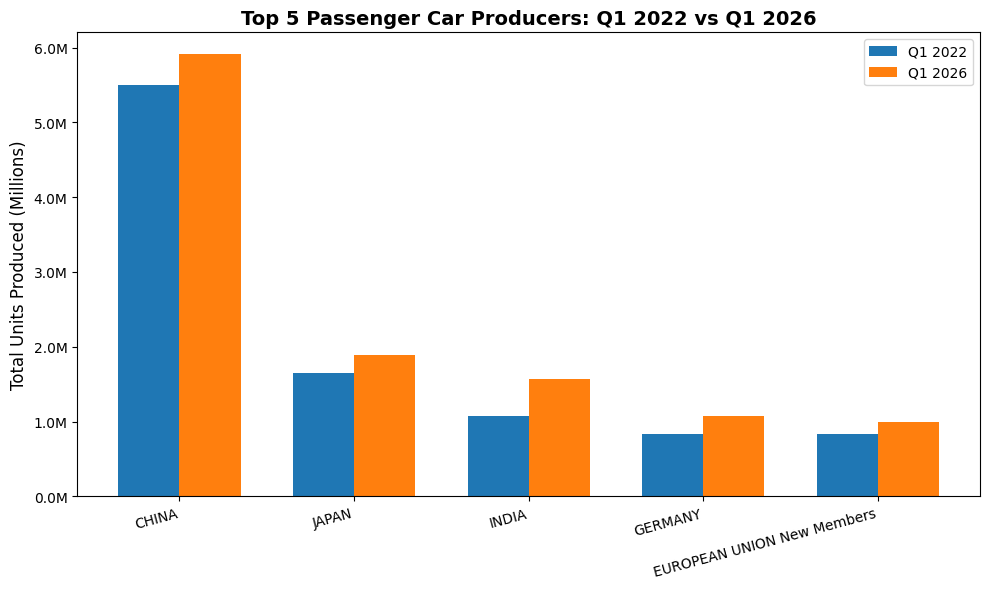

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data for plotting
countries = top_countries['Country_Region'].tolist()
prod_2022 = top_countries['Production_2022'].tolist()
prod_2026 = top_countries['Production_2026'].tolist()

# 2. Set up the bar positions
x = np.arange(len(countries))  # The label locations
width = 0.35  # The width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, prod_2022, width, label='Q1 2022', color='#1f77b4')
rects2 = ax.bar(x + width/2, prod_2026, width, label='Q1 2026', color='#ff7f0e')

# 4. Add labels, title, and formatting
ax.set_ylabel('Total Units Produced (Millions)', fontsize=12)
ax.set_title('Top 5 Passenger Car Producers: Q1 2022 vs Q1 2026', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=15, ha='right')
ax.legend()

# 5. Format the y-axis to show millions (e.g., "6M" instead of "6000000")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(x/1000000)))

# 6. Display the chart cleanly
plt.tight_layout()
plt.show()